In [1]:
import pandas as pd
import numpy as np
import torch

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
nltk.data.path.append('./nltk_data')

#nltk.download('punkt')
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('averaged_perceptron_tagger')

from nltk.corpus import stopwords
from nltk import pos_tag

from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel

import re
import matplotlib.pyplot as plt

from src.encoders import *
from src.parser import *
from src.kmeans_cluster import kmeans_and_score, kmeans_and_score_davies_bouldin
from src.cluster import *

from anomaly_detection import *


Check the size and type of the dataset articles

In [2]:

df_articles = readCSV(path="data/articles.csv")

print(df_articles)
print(df_articles["text"].head())

# length of documents
df_articles["text_length"] = df_articles["text"].apply(len)
print(df_articles["text_length"].describe())



         doc_id                                               text
0     DOC_00001  When I first saw this, I thought for a second ...
1     DOC_00002  The difficulties of a high Isp OTV include: Lo...
2     DOC_00003  Forwarded from Neal Ausman, Galileo Mission Di...
3     DOC_00004  Sjogren's syndrome has been known to induce dr...
4     DOC_00005  Yes, I want to concentrate on other developmen...
...         ...                                                ...
2159  DOC_02160  Punch Imlach's contributions as a coach and GM...
2160  DOC_02161  I have a few reprints left of chapters from my...
2161  DOC_02162  Tom Barrasso wore a great mask, one time, last...
2162  DOC_02163  PATRICK 1st rd: Pens over Isles in 4. Devils o...
2163  DOC_02164  I had exactly the same problem with a 1981 Hor...

[2164 rows x 2 columns]
0    When I first saw this, I thought for a second ...
1    The difficulties of a high Isp OTV include: Lo...
2    Forwarded from Neal Ausman, Galileo Mission Di...
3    S

We compute 2 datasets. 1 base, with stopwords and symbols removed, 2 base but with words lemmanized

In [3]:
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def clean_text_structure(df):
    """Initial cleaning: lowercase and remove non-alphabetic characters."""
    df_clean = df.copy()
    
    df_clean["text"] = df_clean["text"].astype(str).str.lower()
    df_clean["text"] = df_clean["text"].str.replace(r'[^a-z\s]', ' ', regex=True)
    df_clean["text"] = df_clean["text"].str.replace(r'\s+', ' ', regex=True).str.strip()
    return df_clean

def get_aggressive_stopwords():
    """Build an expansive list of noisy words found in your results."""
    base_stops = set(stopwords.words('english'))
    
    custom_noise = {
        'going', 'think', 'way', 'new', 'just', 'come', 'make', 'using', 'deal', 
        'got', 'get', 'would', 'could', 'may', 'might', 'really', 'know', 'want', 
        'like', 'said', 'say', 'need', 'thing', 'take', 'see', 'year', 'also', 
        'well', 'much', 'is', 'who', 'how', 'because', 'first', 'second', 'thought',
        'thanks', 'something', 'find', 'item', 'little', 'point', 'better', 'used', 
        'ref', 'cash', 'many', 'good', 'look', 'people', 'right', 'back', 'even', 
        'two', 'put', 'give', 'tell', 'work', 'please', 'someone', 'anything'
    }
    return base_stops.union(custom_noise)

def apply_filtering(df, is_lemma=False):
    """
    Applies aggressive stopword removal and length filtering.
    is_lemma: Boolean to determine if we use the lemmatizer.
    """
    df_proc = df.copy()
    stop_words = get_aggressive_stopwords()
    lemmatizer = WordNetLemmatizer()

    def process_doc(text):
        words = text.split()
        if is_lemma:
            words = [lemmatizer.lemmatize(w) for w in words]
        filtered = [w for w in words if w not in stop_words and len(w) > 2]
        return ' '.join(filtered)

    df_proc["text"] = df_proc["text"].apply(process_doc)
    
    mask = df_proc["text"].str.split().str.len() > 5
    return df_proc[mask]


df_initial = clean_text_structure(df_articles)
df_base_full = apply_filtering(df_initial, is_lemma=False)
df_base = df_base_full["text"]

df_lemma_full = apply_filtering(df_initial, is_lemma=True)
df_lemma = df_lemma_full["text"]

print(f"Base docs remaining: {df_base.head()}")
print(f"Lemma docs remaining: {df_lemma.head()}")

Base docs remaining: 0    saw headline star pliers found srb recently so...
1    difficulties high isp otv include long transfe...
2    forwarded neal ausman galileo mission director...
3    sjogren syndrome known induce dryness vaginal ...
4    yes concentrate development issues created gra...
Name: text, dtype: str
Lemma docs remaining: 0    saw headline star plier found srb recently som...
1    difficulty high isp otv include long transfer ...
2    forwarded neal ausman galileo mission director...
3    sjogren syndrome known induce dryness vaginal ...
4    yes concentrate development issue created grap...
Name: text, dtype: str


Create objects of the encoders with each dataset. We use Bag of words, TF-IDF and Word2Vec. Use 0.1 and 0.3 df

In [4]:
# --- BoW ENCODERS ---
bow_base_3 = BoWEncoder(df_base)
bow_base_3.fit(max_df=0.3)
bow_base_1 = BoWEncoder(df_base)
bow_base_1.fit(max_df=0.1)

bow_lemma_3 = BoWEncoder(df_lemma)
bow_lemma_3.fit(max_df=0.3)
bow_lemma_1 = BoWEncoder(df_lemma)
bow_lemma_1.fit(max_df=0.1)

# --- TF-IDF ENCODERS ---
tf_base_3 = TFEncoder(df_base)
tf_base_3.fit(max_df=0.3)
tf_base_1 = TFEncoder(df_base)
tf_base_1.fit(max_df=0.1)

tf_lemma_3 = TFEncoder(df_lemma)
tf_lemma_3.fit(max_df=0.3)
tf_lemma_1 = TFEncoder(df_lemma)
tf_lemma_1.fit(max_df=0.1)

# --- Word2Vec ENCODERS ---
w2v_base = Word2VecEncoder(df_base)
w2v_base.fit()
w2v_lemma = Word2VecEncoder(df_lemma)
w2v_lemma.fit()

First test agains kmeans. Run against each dataset and encoder for k between 2-10. Plot the best result.
Score using Silhouette.

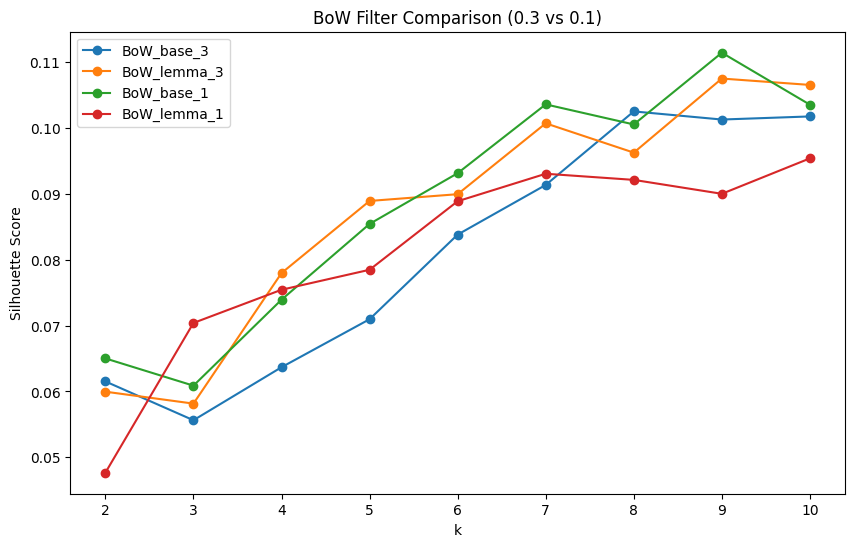

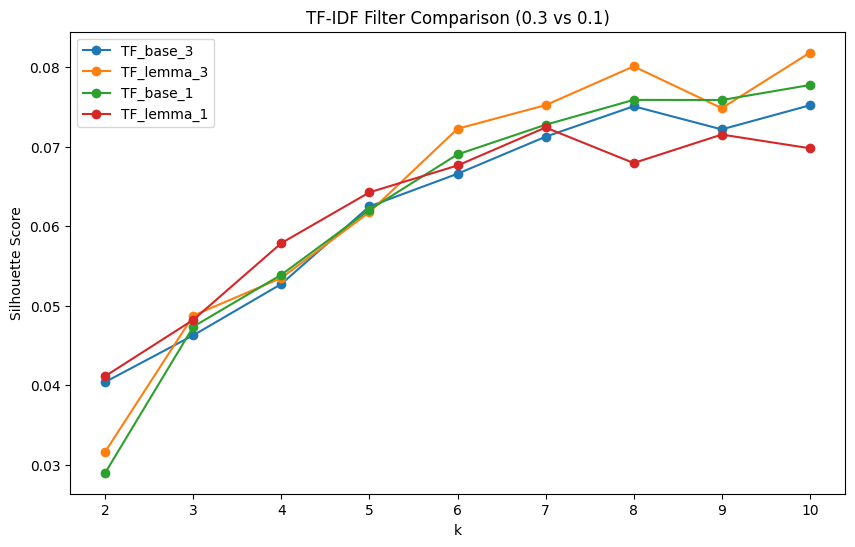

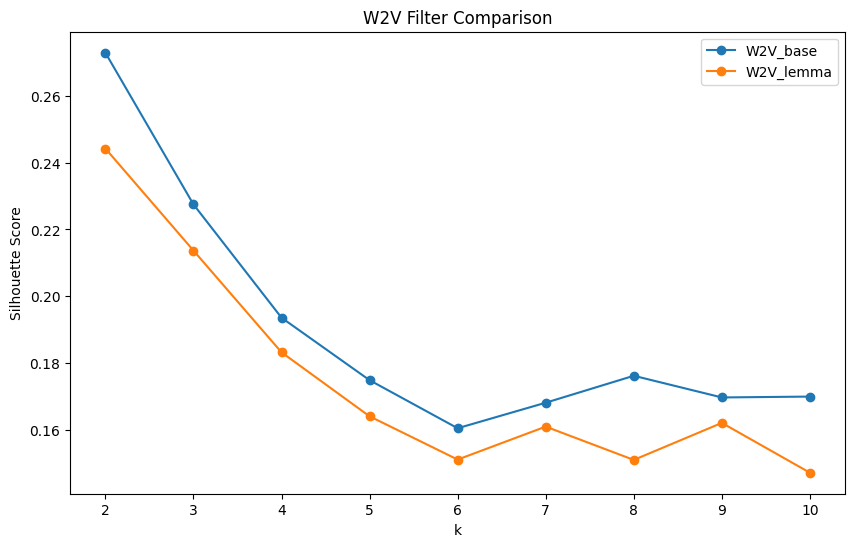

In [5]:
bow_results = {
    "BoW_base_3": kmeans_and_score(bow_base_3, 20),
    "BoW_lemma_3": kmeans_and_score(bow_lemma_3, 20),
    "BoW_base_1": kmeans_and_score(bow_base_1, 20),
    "BoW_lemma_1": kmeans_and_score(bow_lemma_1, 20)
}

tf_results = {
    "TF_base_3": kmeans_and_score(tf_base_3, 20),
    "TF_lemma_3": kmeans_and_score(tf_lemma_3, 20),
    "TF_base_1": kmeans_and_score(tf_base_1, 20),
    "TF_lemma_1": kmeans_and_score(tf_lemma_1, 20)
}

w2v_results = {
    "W2V_base": kmeans_and_score(w2v_base, 20),
    "W2V_lemma": kmeans_and_score(w2v_lemma, 20),
}

# Run the plots
plot_results(bow_results, "BoW Filter Comparison (0.3 vs 0.1)")
plot_results(tf_results, "TF-IDF Filter Comparison (0.3 vs 0.1)")
plot_results(w2v_results, "W2V Filter Comparison")

Double check against Davies-Bouldin score. Lower is better here

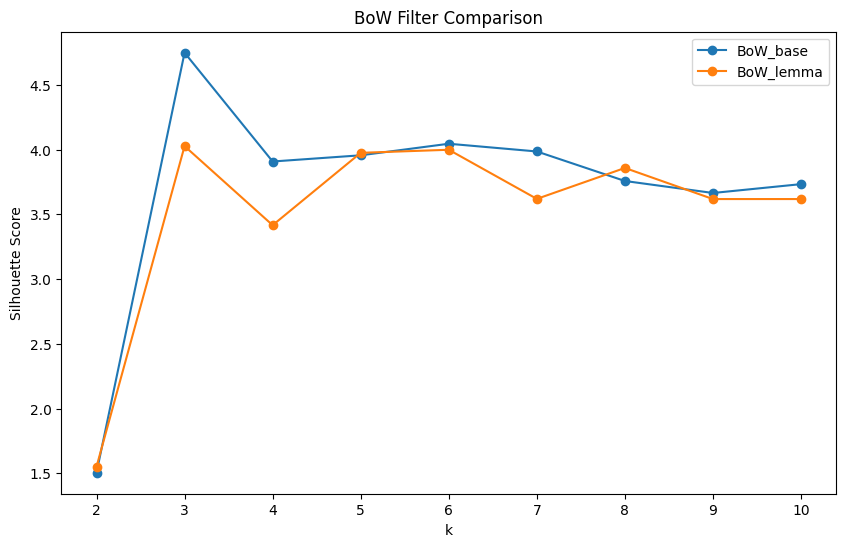

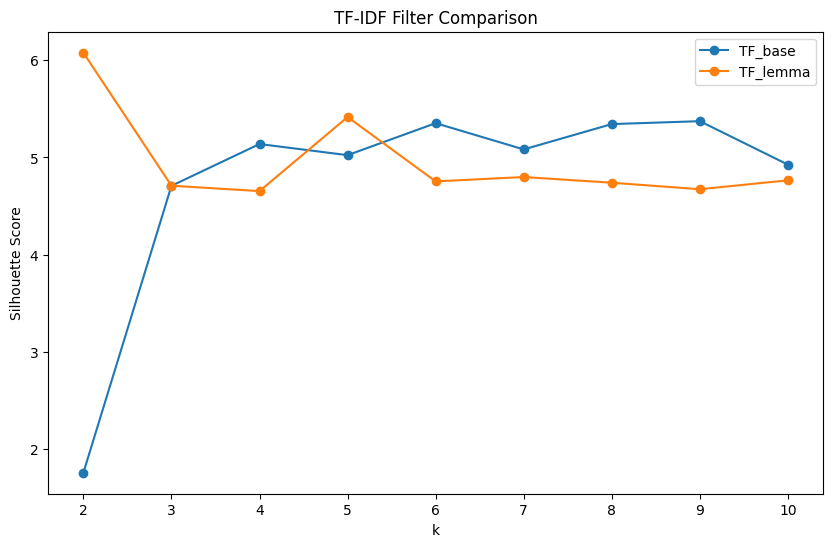

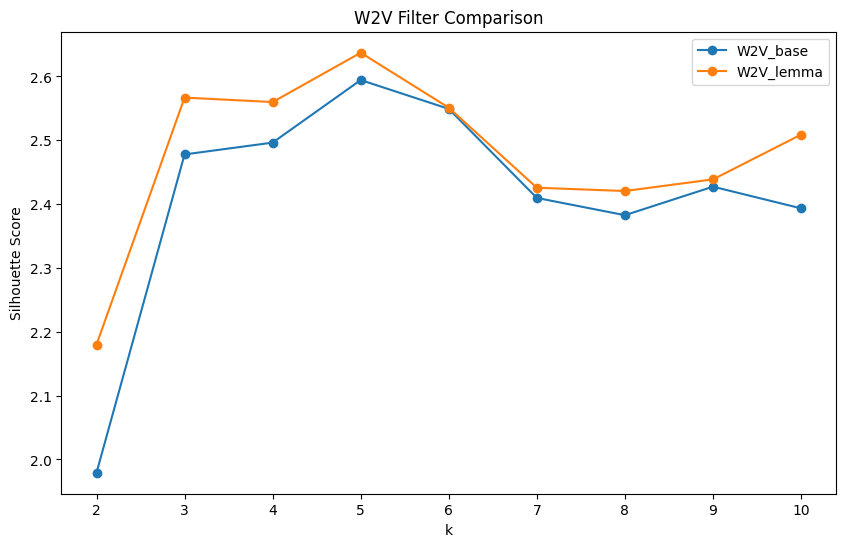

In [6]:


bow_results_d = {
    "BoW_base": kmeans_and_score_davies_bouldin(bow_base_3, 20),
    "BoW_lemma": kmeans_and_score_davies_bouldin(bow_lemma_3, 20)
}

tf_results_d = {
    "TF_base": kmeans_and_score_davies_bouldin(tf_base_3, 20),
    "TF_lemma": kmeans_and_score_davies_bouldin(tf_lemma_3, 20)
}

w2v_results_d = {
    "W2V_base": kmeans_and_score_davies_bouldin(w2v_base, 20),
    "W2V_lemma": kmeans_and_score_davies_bouldin(w2v_lemma, 20)
}

plot_results(bow_results_d, "BoW Filter Comparison")
plot_results(tf_results_d, "TF-IDF Filter Comparison")
plot_results(w2v_results_d, "W2V Filter Comparison")

Visualize all the results using MDS and heatmaps

Running MDS for BoW_base_3 on 400 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Running MDS for BoW_lemma_3 on 396 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Running MDS for BoW_base_1 on 393 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Running MDS for BoW_lemma_1 on 400 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


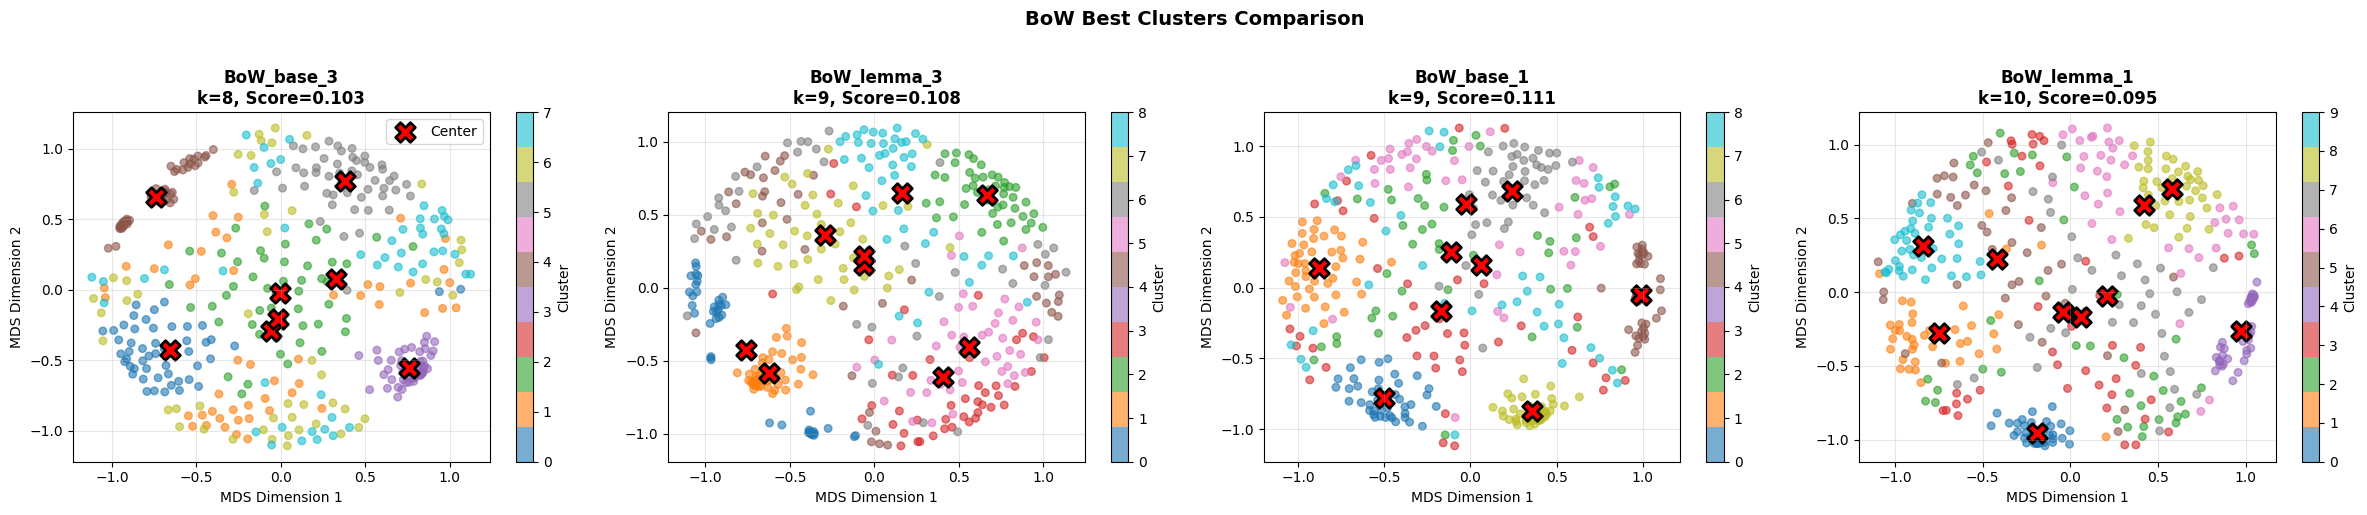

Running MDS for TF_base_3 on 398 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Running MDS for TF_lemma_3 on 370 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Running MDS for TF_base_1 on 394 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Running MDS for TF_lemma_1 on 392 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


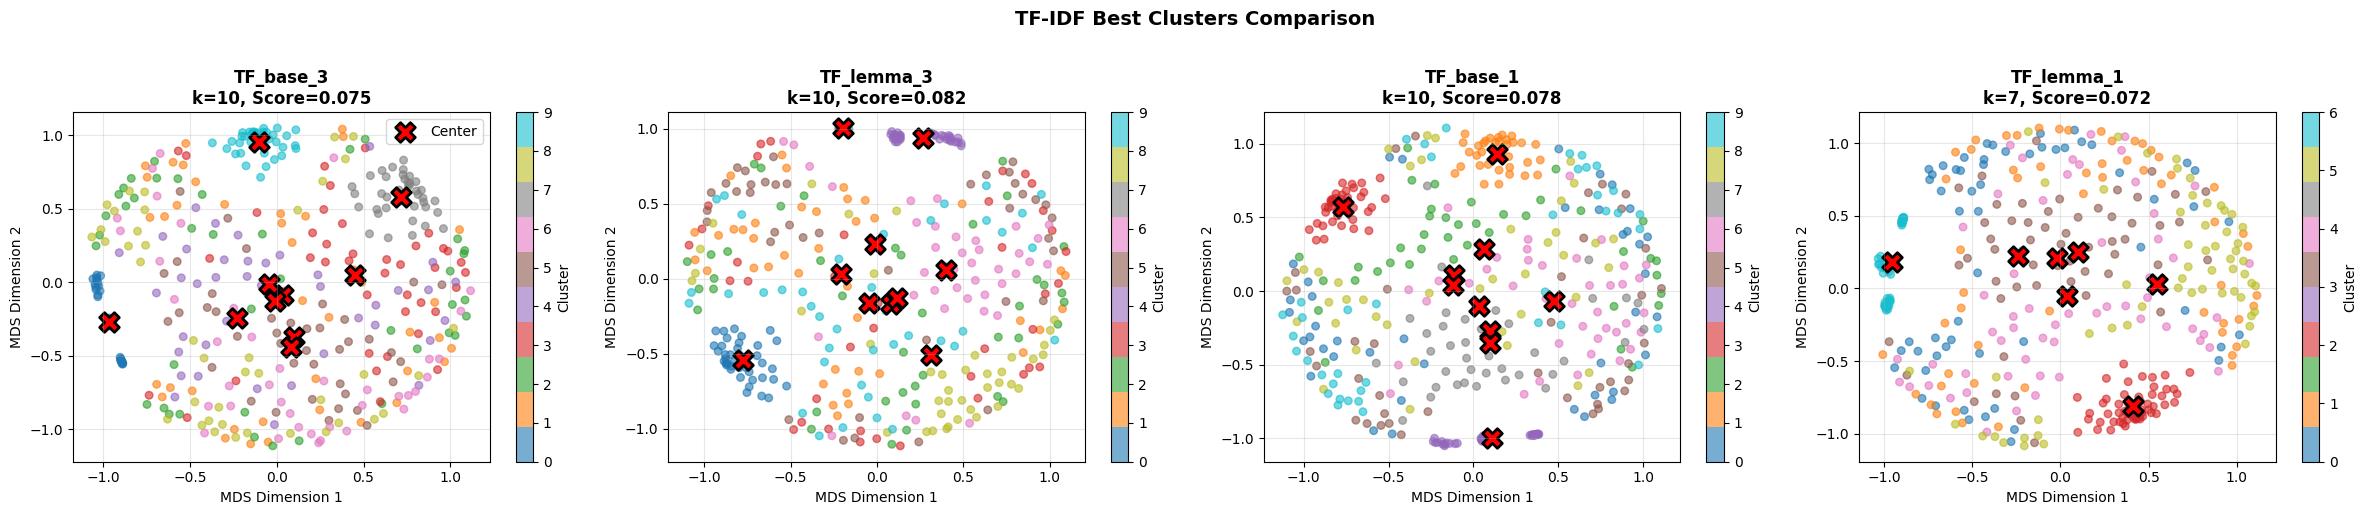

Running MDS for W2V_base on 400 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Running MDS for W2V_lemma on 400 documents...


/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/mnt/storage/projects/DataMining/3/DataMining_assignment3/venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


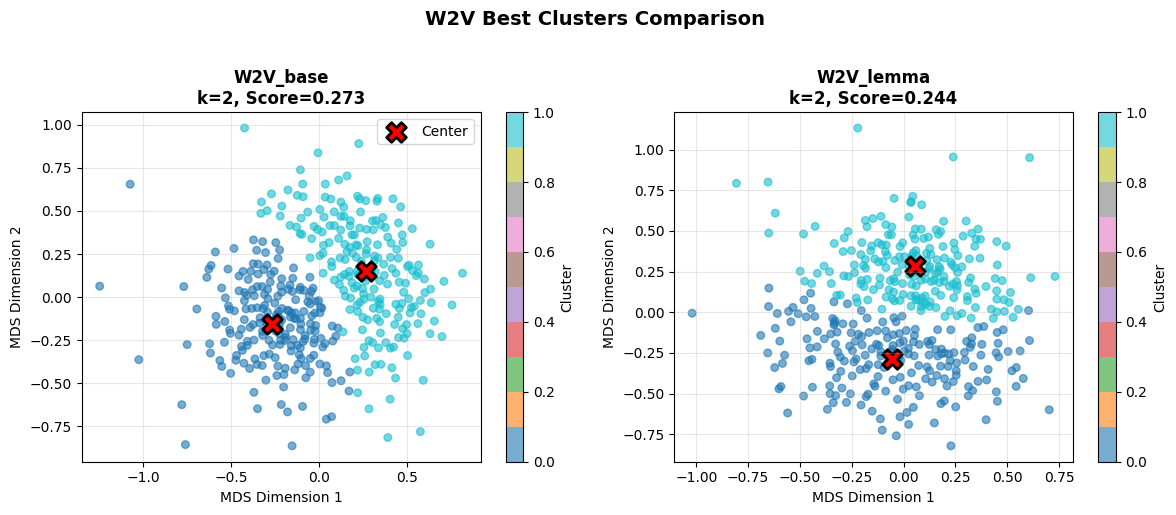

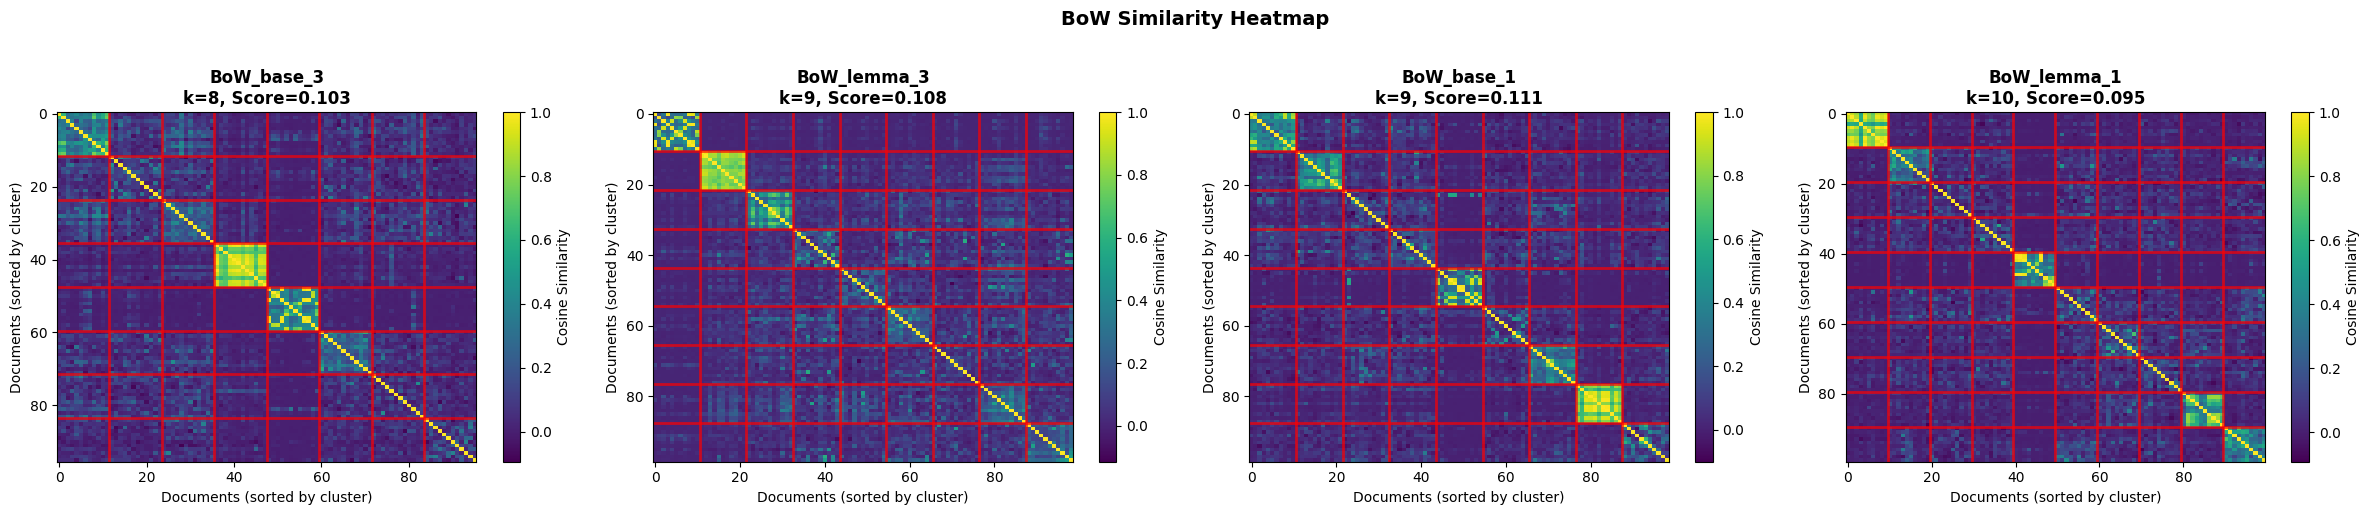

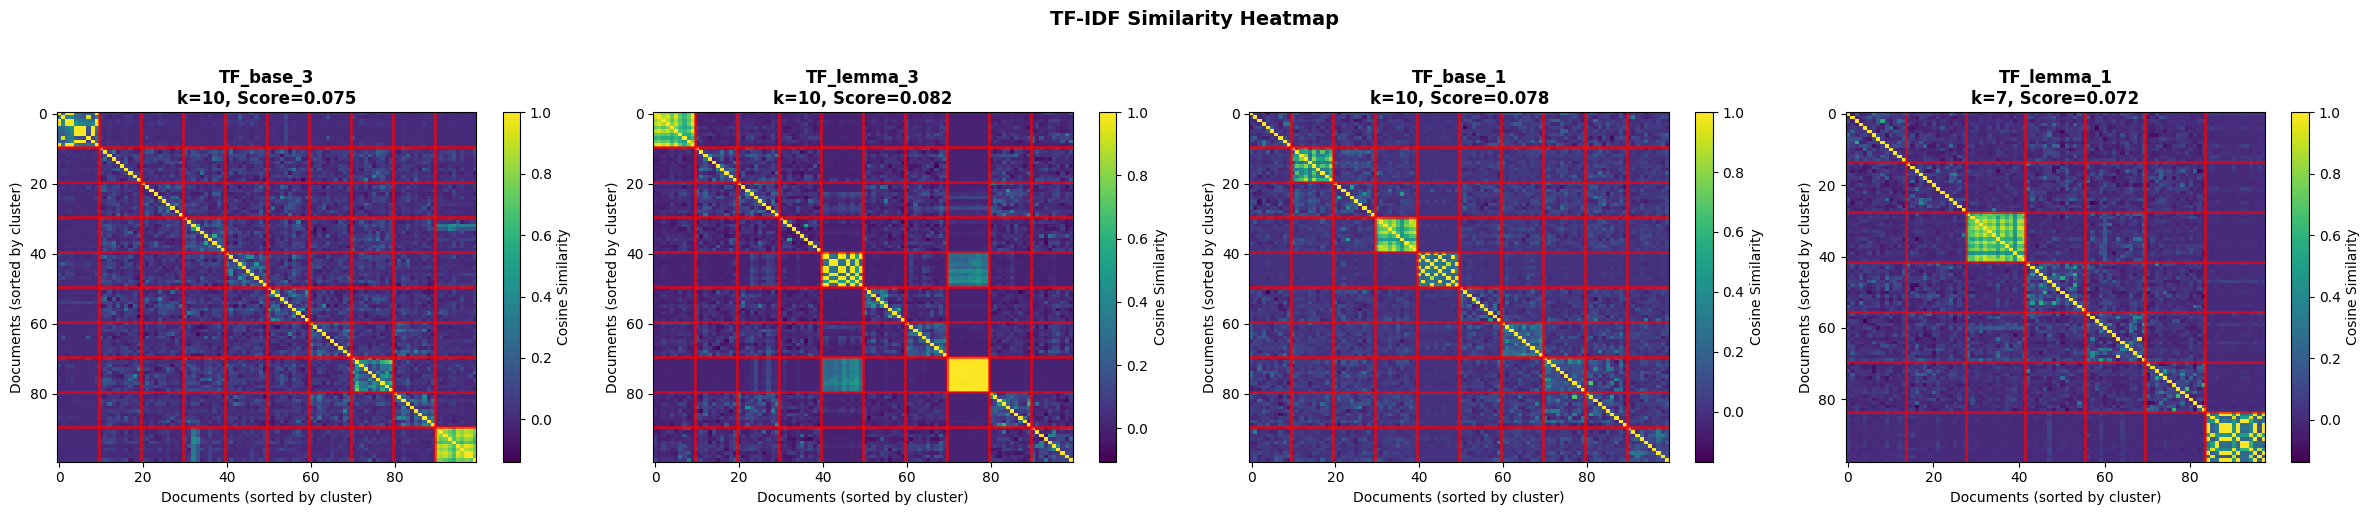

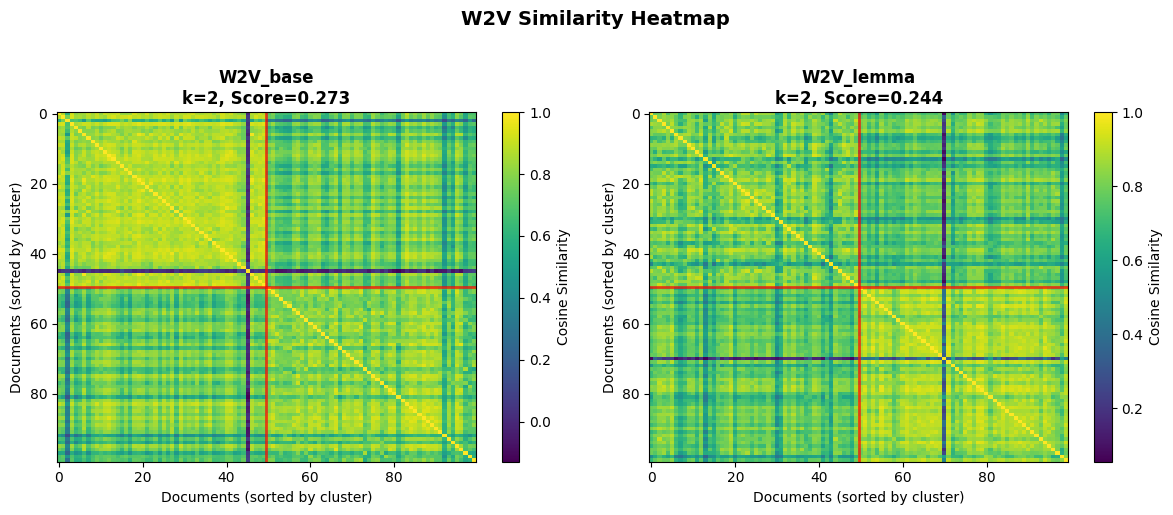

In [7]:
# MDS
visualize_best_clusters(
    bow_results,
    "BoW Best Clusters Comparison",
    method='mds'
)

visualize_best_clusters(
    tf_results,
    "TF-IDF Best Clusters Comparison",
    method='mds'
)

visualize_best_clusters(
    w2v_results,
    "W2V Best Clusters Comparison",
    method='mds'
)

# Similarity heatmaps
visualize_best_clusters(
    bow_results,
    "BoW Similarity Heatmap",
    method='heatmap'
)

visualize_best_clusters(
    tf_results,
    "TF-IDF Similarity Heatmap",
    method='heatmap'
)

visualize_best_clusters(
    w2v_results,
    "W2V Similarity Heatmap",
    method='heatmap'
)

We choose the best performing encoder and continue against all clustering algorithms.
We have, Kmeans, Hierarchical and Spectral.

We continue with bow_base_1


Clustering Summary
Best k: 9
Best silhouette score: 0.0684

Cluster sizes:
  Cluster 0: 41 documents
  Cluster 1: 173 documents
  Cluster 2: 369 documents
  Cluster 3: 615 documents
  Cluster 4: 51 documents
  Cluster 5: 341 documents
  Cluster 6: 128 documents
  Cluster 7: 73 documents
  Cluster 8: 373 documents

Top 10 terms per cluster:

Cluster 0:
  accurate (1.992), accused (1.184), abs (0.797), acknowledge (0.600), ability (0.524), accepted (0.490), actually (0.456), absolute (0.439), across (0.439), accompanied (0.391)

Cluster 1:
  acceleration (1.444), acceptance (0.793), abs (0.745), accelerator (0.697), ability (0.551), accessible (0.469), accident (0.352), abused (0.304), accidents (0.224), access (0.183)

Cluster 2:
  abs (1.109), ability (0.703), acceptable (0.198), academy (0.134), acm (0.130), aberrant (0.115), accompanied (0.114), adjustment (0.105), able (0.103), acid (0.096)

Cluster 3:
  abs (0.692), ability (0.577), abdominal (0.452), absolute (0.317), able (0.257

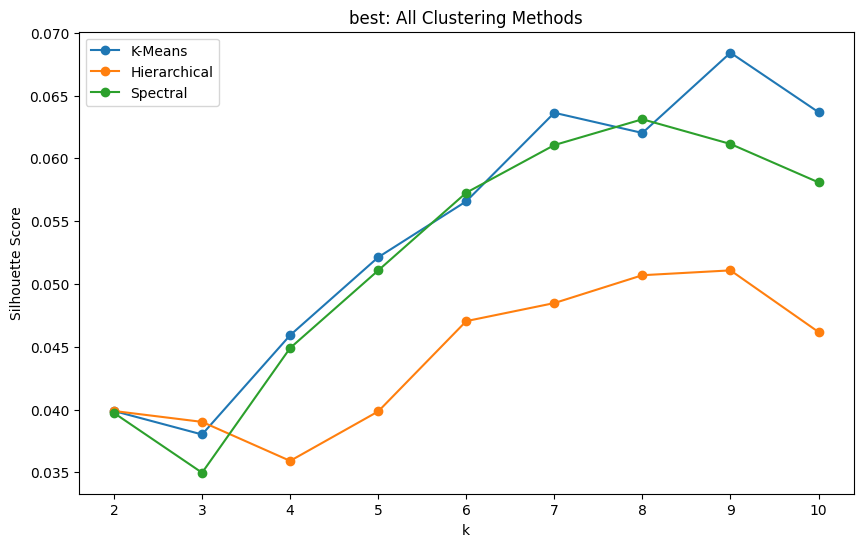

In [8]:
best_enc = bow_base_1

# K-means
best_kmeans = cluster_and_score(best_enc, method='kmeans', n_init=20)
print_cluster_summary(best_kmeans)

# Hierarchical
best_hierarchical = cluster_and_score(best_enc, method='hierarchical', linkage='ward')
print_cluster_summary(best_hierarchical)

# Spectral
best_spectral = cluster_and_score(best_enc, method='spectral', n_init=10, affinity='rbf')
print_cluster_summary(best_spectral)

# Compare all three
best_all_methods = {
    "K-Means": best_kmeans,
    "Hierarchical": best_hierarchical,
    "Spectral": best_spectral
}
plot_results(best_all_methods, "best: All Clustering Methods")

Use the best method for the cluster.csv. This was bow_base_1 with kmeans k=10

In [9]:
best_enc = bow_base_1

k = 10
kmeans = KMeans(
    n_clusters=k,
    n_init=20,
    random_state=42
)

labels = kmeans.fit_predict(best_enc.norm_matrix)

clusters_df = pd.DataFrame({
    "doc_id": df_articles["doc_id"],
    "cluster": labels
})

clusters_df = clusters_df.sort_index()
output_path = "data/clusters.csv"
clusters_df.to_csv(output_path, index=False)

print(f"clusters.csv saved to: {output_path}")
print(clusters_df.head())

clusters.csv saved to: data/clusters.csv
      doc_id  cluster
0  DOC_00001        3
1  DOC_00002        3
2  DOC_00003        3
3  DOC_00004        9
4  DOC_00005        5


Compute abomalies and print the results

In [10]:
def print_anomaly_articles(result, df, n=10, text_col="text"):
    anomaly_indices = result["anomaly_indices"]

    print("\n" + "="*80)
    print(f"TOP {n} ANOMALY ARTICLES")
    print("="*80)

    for i, idx in enumerate(anomaly_indices[:n]):
        row = df.iloc[idx]

        print(f"\n[{i+1}] DOC_ID: {row['doc_id']}")
        print("-"*60)

        text = str(row[text_col])

        if len(text) > 500:
            text = text[:500] + " ..."

        print(text)

best_enc = bow_base_1

lof_result = detect_anomalies(
    best_enc,
    method='lof',
    n_anomalies=50,
    n_neighbors=20
)

print_anomaly_summary(lof_result, df_articles)
print_anomaly_articles(lof_result, df_articles, n=10)

iso_result = detect_anomalies(best_enc, method='isolation_forest', n_anomalies=50)

print_anomaly_summary(iso_result, df_articles)
print_anomaly_articles(iso_result, df_articles, n=10)

save_anomalies_csv(lof_result, df_articles, 'data/anomalies.csv')


Anomaly Detection Summary (LOF)
Number of anomalies detected: 50

Top 10 most anomalous documents:
  1. DOC_00375 (score: 7.2477)
  2. DOC_01007 (score: 5.0741)
  3. DOC_01312 (score: 4.8860)
  4. DOC_00607 (score: 4.4490)
  5. DOC_02071 (score: 4.3274)
  6. DOC_00853 (score: 4.0005)
  7. DOC_01249 (score: 3.9448)
  8. DOC_01199 (score: 3.8832)
  9. DOC_02054 (score: 3.7986)
  10. DOC_00549 (score: 3.7079)

Anomaly score statistics:
  Min: 0.9598
  Max: 7.2477
  Mean: 1.1135
  Anomaly threshold: 1.6249

TOP 10 ANOMALY ARTICLES

[1] DOC_ID: DOC_00375
------------------------------------------------------------
Also photoshopII is out soon, has anyone got a date and any cofmments? Andy _______________________________________________________ | Andrew Leahy | aleahy@cch.coventry.ac.uk | Odd FROG | ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

[2] DOC_ID: DOC_01007
------------------------------------------------------------
[reply to geb@cs.pitt.edu (Gordon Banks)] I made a dec